# NOVA 4a/4b subdivision

**What this notebook investigates:**
Is NOVA 4 internally homogeneous, or does it contain a meaningful subdivision between products that use predominantly natural additives versus those built around synthetic ones?

**Analysis pipeline:**
1. Load and subset NOVA 4 products from the imputed dataset
2. Exploratory data analysis of additive feature distributions
3. Determine optimal k via elbow method and silhouette scores
4. Fit KMeans (k=2) and interpret cluster profiles
5. Validate clusters against Nutri-Score
6. Train a LightGBM binary classifier on the cluster pseudo-labels
7. SHAP analysis to explain which features drive the subdivision

# 1. Setup and subset to NOVA 4

In [243]:

# Loading packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from huggingface_hub import hf_hub_download
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, ConfusionMatrixDisplay

# for SHAP analysis
%pip install shap
import shap


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sofiebojgaardthomsen/Documents/Data_Science/DataScience2026/env/lib/python3.11/site-packages/pip/__main__.py", line 8, in <module>
    if sys.path[0] in ("", os.getcwd()):
                           ^^^^^^^^^^^
PermissionError: [Errno 1] Operation not permitted
Note: you may need to restart the kernel to use updated packages.


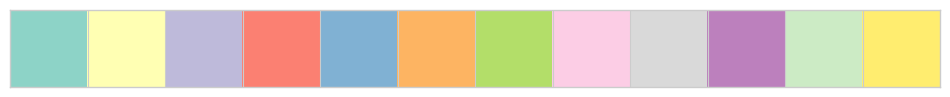

In [244]:
# Global plotting style for this notebook
sns.set_theme(
    style="whitegrid",
    palette="Set3",
    context="paper"
)

# and in order to specify the colors from the set
# remember they are 0-indexed
set3 = sns.color_palette("Set3")
sns.palplot(set3)
plt.show()


In [245]:
# Load data - REMEMBER TO CHANGE WORKING DIRECTORY
# also, this only works if you have the token in a txt-file in the working directory
with open("/Users/sofiebojgaardthomsen/Documents/Data_Science/DataScience2026/token.txt", "r") as f:
    token = f.read().strip()


In [246]:
# Download the raw file
path = hf_hub_download(
    repo_id="MattiWhen/ImputedNovaOpenFoodFacts",
    filename="with_imputed_nova.parquet",  # adjust filename if different
    repo_type="dataset",
    token=token
)

df_train = pd.read_parquet(path)

In [248]:
# making the nova group 4 data 
# The subdivision analysis focuses exclusively on ultra-processed foods (NOVA 4)
df_nova4 = df_train[df_train['nova_group'] == 4].copy()

# Inspect data
print(f"NOVA 4 products: {len(df_nova4):,}")
print(f"\nAvailable columns:")
print(df_nova4.columns.tolist())

NOVA 4 products: 196,881

Available columns:
['product_name', 'brands', 'nova_group', 'nutriscore_score', 'nutriscore_grade', 'lang', 'languages_tags', 'ingredients_original_tags', 'code', 'product_name_clean', 'product_ID', 'ingredients_parsed', 'ingredients_clean', 'additive_count', 'has_additive', 'natural_additive_count', 'synthetic_additive_count', 'debated_additive_count', 'has_synthetic_only', 'has_natural_only', 'colorant_count', 'preservative_count', 'antioxidant_count', 'emulsifier_count', 'acidity_count', 'flavour_count', 'antibiotics_count', 'sweetener_count', 'extras_count', 'ingredient_count', 'nova_mord', 'nova_lgbm', 'model_agreement']


# 2. Exploring the data

In [287]:
# investigate these columns
count_cols = [
    'additive_count', 'natural_additive_count', 'synthetic_additive_count',
    'debated_additive_count', 'emulsifier_count', 'preservative_count',
    'sweetener_count', 'colorant_count', 'antioxidant_count', 'acidity_count', 
    'flavour_count', 'extras_count'
]

flag_cols = ['has_additive', 'has_synthetic_only', 'has_natural_only']

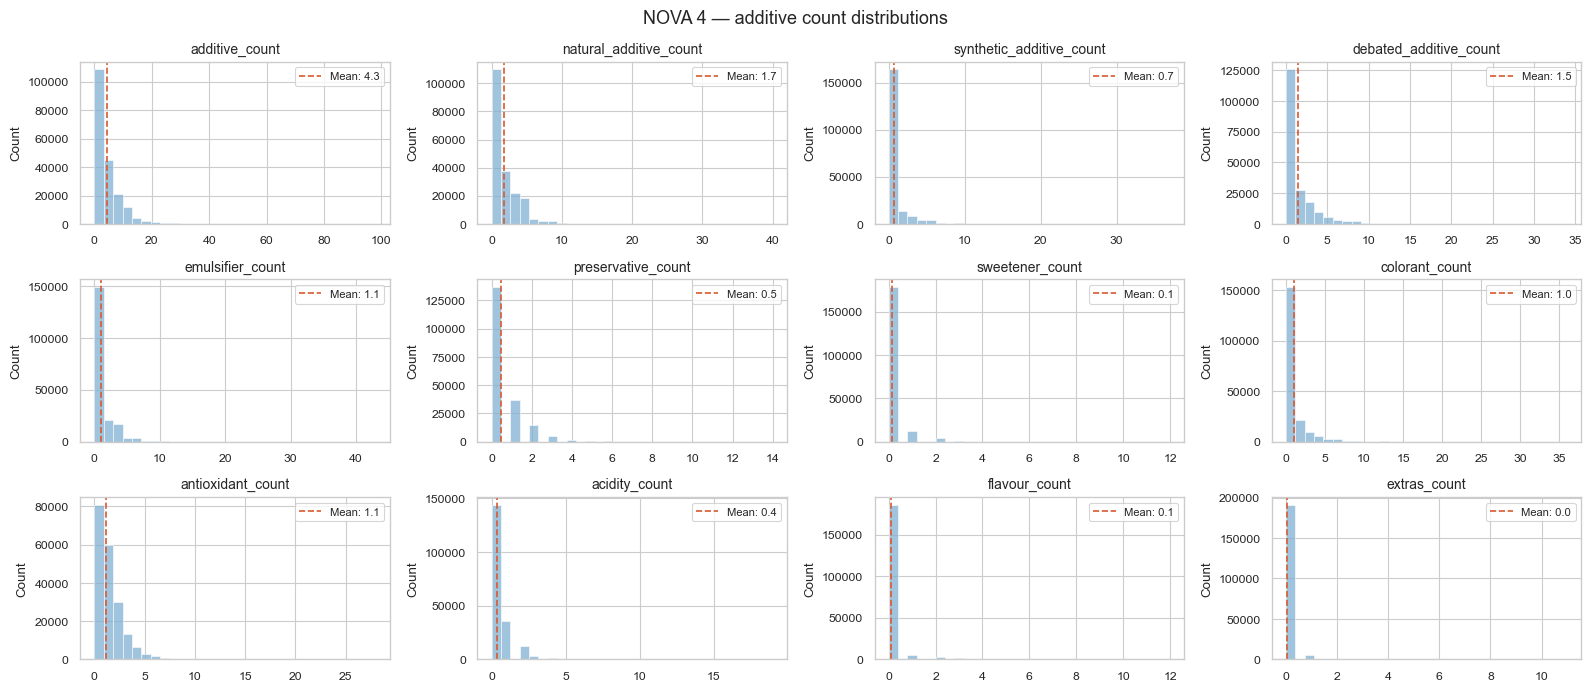

In [288]:
# Plot 1: count distributions 
fig, axes = plt.subplots(3, 4, figsize=(16, 7))
fig.suptitle('NOVA 4 additive count distributions', fontsize=13)

for ax, col in zip(axes.flatten(), count_cols):
    sns.histplot(df_nova4[col], bins=30, ax=ax, 
                 edgecolor='white', color=set3[4],linewidth=0.4)
    ax.axvline(df_nova4[col].mean(), linestyle='--', color='#D85A30',
               linewidth=1.2, label=f'Mean: {df_nova4[col].mean():.1f}')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [307]:
# reason to drop the antibiotics_count column -> they are not present at all
df_nova4['antibiotics_count'].value_counts()

antibiotics_count
0    196881
Name: count, dtype: int64

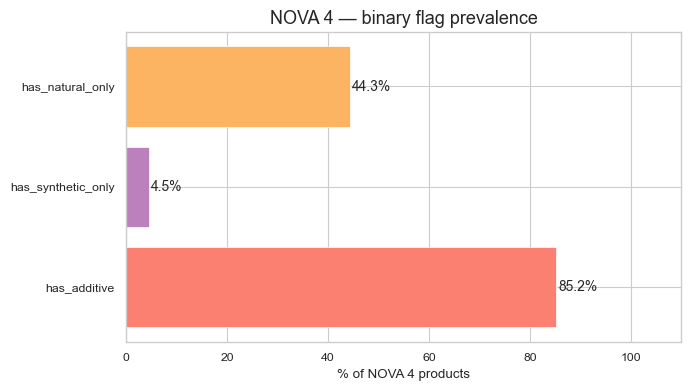

In [290]:
# Plot 2: binary flag prevalence
flag_pct = df_nova4[flag_cols].mean() * 100  # % of products where flag == 1

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(flag_pct.index, flag_pct.values,
            color=[set3[3], set3[9], set3[5]],
            edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10)

ax.set_xlabel('% of NOVA 4 products')
ax.set_xlim(0, 110)
ax.set_title('NOVA 4 binary flag prevalence', fontsize=13)
plt.tight_layout()
plt.show()

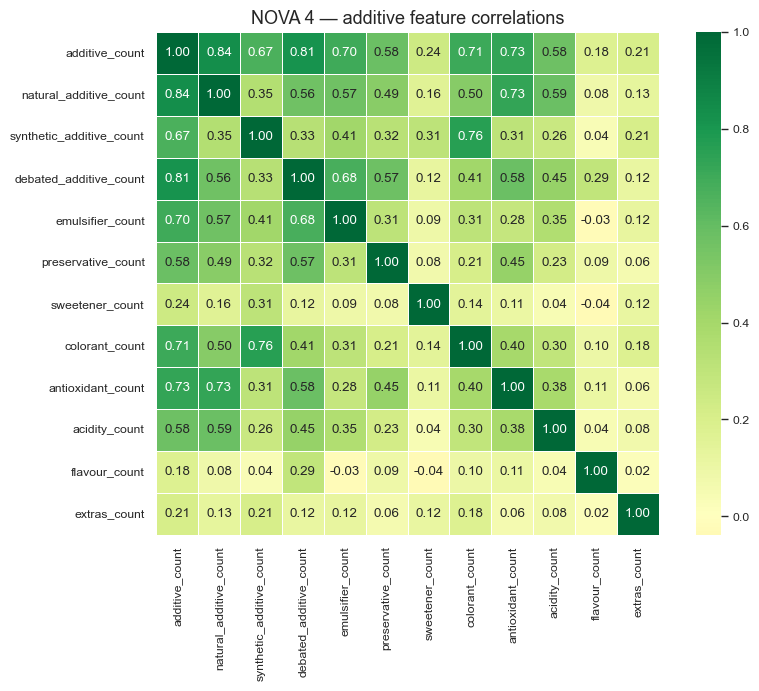

In [291]:
# Plot 3: Additive feature correlations
# making a plot to investigate the additive feature correlations
fig, ax = plt.subplots(figsize=(9, 7))
corr = df_nova4[count_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('NOVA 4 additive feature correlations', fontsize=13)
plt.tight_layout()
plt.show()

# Feature selection for K-Means

We restrict features to additive-level counts and functional categories.

In [293]:
# Final feature set for K-Means clustering
final_feature_cols = [
'additive_count', 
'natural_additive_count', 
'synthetic_additive_count', 
'debated_additive_count', 
'colorant_count', 
'preservative_count', 
'antioxidant_count', 
'emulsifier_count', 
'acidity_count', 
'flavour_count', 
'sweetener_count', 
'extras_count'
]

# 3. Determine the optimal K

Two complementary methods are used to evaluate the optimal number of clusters:
- **Elbow method**: plots inertia (within-cluster sum of squares) against k; the optimal k is at the 'elbow' where it flattens most sharply.
- **Silhouette score**: for each point, measures how similar it is to its own cluster versus the nearest other cluster (range: −1 to 1; higher is better). The k with the highest score is preferred.

In [294]:
# Scale features
# K-Means is distance-based, so features on different scales will dominate the clustering. 
# StandardScaler centres each feature to mean=0, std=1 so that all features contribute equally to Euclidean distance calculations.
# Without scaling, variables like 'additive_count' would dominate the clustering.
scaler = StandardScaler()
X_nova4 = scaler.fit_transform(df_nova4[final_feature_cols])

In [324]:
# ── Compute inertia and silhouette scores for k = 1..10 ───────────────────────
# this took 48 minutes to run last time when n_init was 5! So, have patience:)

# setting up the loop
k_range = range(1, 11)
inertias = []
sil_scores = []  # silhouette is undefined for k=1, so we fill with NaN

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) #runs the K-Means clustering for each k
    labels = km.fit_predict(X_nova4) # assigns a label for each product
    inertias.append(km.inertia_) # prepares the inertia, i.e. the total within-cluster sum of squared distances for the elbow plot
    if k > 1: # as silhouette scores measures how well-separated clusters are from each other k=1 does not mathematically have a silhouette score
        sil_scores.append(silhouette_score(X_nova4, labels)) # computes the silhouette score
    else:
        sil_scores.append(np.nan)

# and to inspect the initial values
print("Silhouette scores by k:")
for k, s in zip(k_range, sil_scores):
    if not np.isnan(s):
        print(f"  k={k}: {s:.4f}")

Silhouette scores by k:
  k=2: 0.4988
  k=3: 0.3457
  k=4: 0.3532
  k=5: 0.3570
  k=6: 0.3596
  k=7: 0.2741
  k=8: 0.2693
  k=9: 0.2866
  k=10: 0.2965


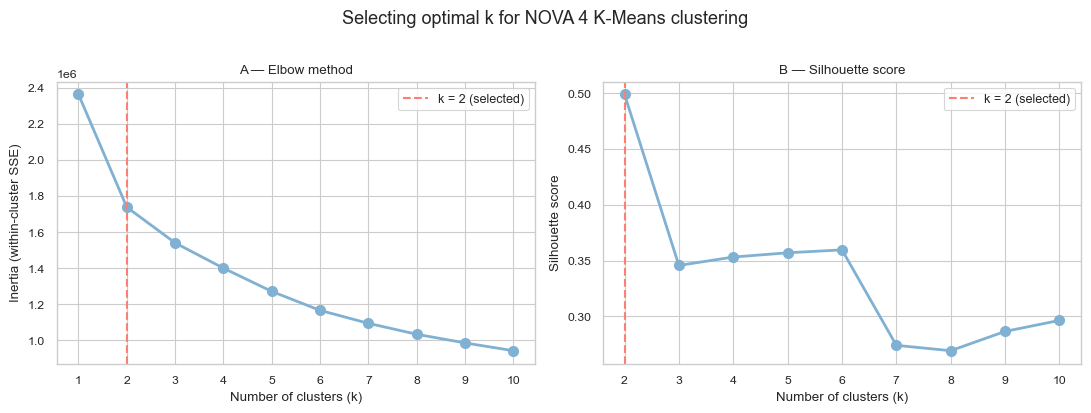

In [325]:
# Combined k-selection figure
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Selecting optimal k for NOVA 4 K-Means clustering', fontsize=13, y=1.02)

k_vals = list(k_range)

# Panel A: Elbow method
ax = axes[0]
ax.plot(k_vals, inertias, marker='o', linewidth=2, markersize=7, color=set3[4])
ax.axvline(2, color=set3[3], linestyle='--', linewidth=1.5, label='k = 2 (selected)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster SSE)')
ax.set_title('A — Elbow method')
ax.set_xticks(k_vals)
ax.legend(fontsize=9)

# Panel B: Silhouette scores
ax = axes[1]
sil_vals = [s for s in sil_scores if not np.isnan(s)]
sil_ks   = [k for k, s in zip(k_vals, sil_scores) if not np.isnan(s)]
ax.plot(sil_ks, sil_vals, marker='o', linewidth=2, markersize=7, color=set3[4])
ax.axvline(2, color=set3[3], linestyle='--', linewidth=1.5, label='k = 2 (selected)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('B — Silhouette score')
ax.set_xticks(sil_ks)
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('nova4_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. K-Means Clustering (k=2)

In [326]:
# Fit final K-Means model
# n_clusters=2: chosen due to the elbow method and silhouette score above
# n_init=20: runs K-Means 20 times with different centroid seeds and keeps the best result.
# random_state=42: ensures reproducibility.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
df_nova4['nova4_cluster'] = kmeans.fit_predict(X_nova4)

# Sanity check: both clusters should be non-empty
cluster_counts = df_nova4['nova4_cluster'].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_counts)

Cluster sizes:
nova4_cluster
0     32670
1    164211
Name: count, dtype: int64


In [327]:
# Silhouette score for the final model 
# Silhouette score measures how well each point fits its assigned cluster:
#   s = (b - a) / max(a, b)
# where a = mean intra-cluster distance, b = mean nearest-cluster distance.
# Range: -1 (wrong cluster) to +1 (tight, well-separated clusters).
final_sil = silhouette_score(X_nova4, df_nova4['nova4_cluster'])
print(f"Final silhouette score (k=2): {final_sil:.3f}")

Final silhouette score (k=2): 0.500


In [328]:
# Cluster centres (back to the original units)
# inverse_transform converts the scaled cluster centroids back to the original feature scale for interpretable reporting.
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=final_feature_cols
)
cluster_centers.index = ['Cluster 0 (NOVA 4a)', 'Cluster 1 (NOVA 4b)'] #assigning pseudo-labels
cluster_centers.round(2)

,additive_count,natural_additive_count,synthetic_additive_count,debated_additive_count,colorant_count,preservative_count,antioxidant_count,emulsifier_count,acidity_count,flavour_count,sweetener_count,extras_count
Cluster 0 (NOVA 4a),12.57,4.56,2.53,4.42,2.94,1.45,3.06,3.17,1.23,0.25,0.34,0.11
Cluster 1 (NOVA 4b),2.71,1.16,0.37,0.94,0.59,0.30,0.77,0.66,0.22,0.07,0.09,0.02


# Cluster visualisations

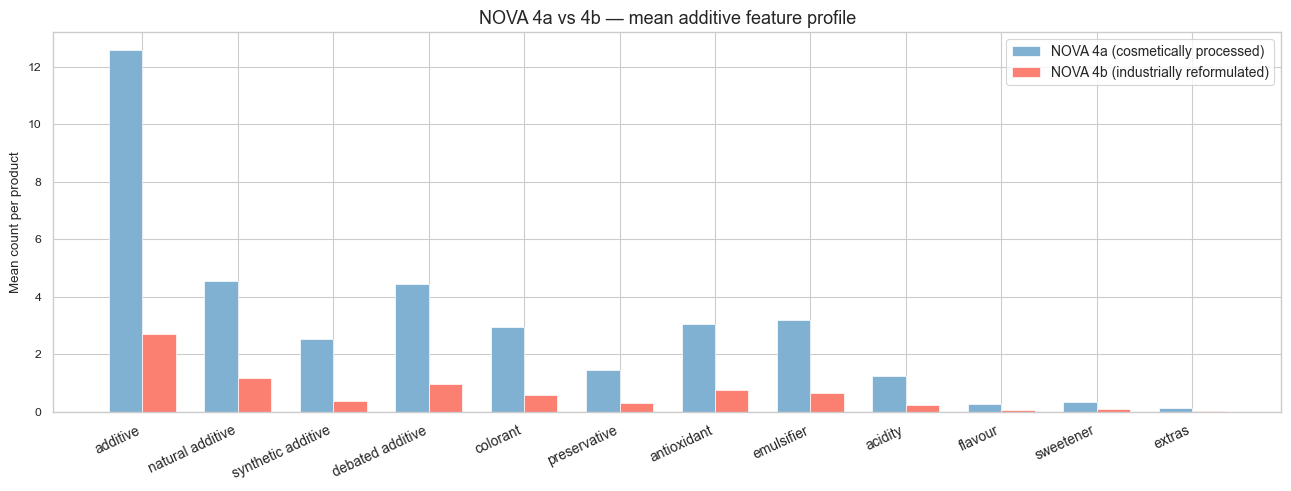

In [329]:
# Cluster profiles — mean feature values 
# A grouped bar chart showing the mean value of each additive feature broken down by cluster. 

profile_cols = [
    'additive_count', 
    'natural_additive_count', 
    'synthetic_additive_count', 
    'debated_additive_count', 
    'colorant_count', 
    'preservative_count', 
    'antioxidant_count', 
    'emulsifier_count', 
    'acidity_count', 
    'flavour_count', 
    'sweetener_count', 
    'extras_count'
]

profile = df_nova4.groupby('nova4_cluster')[profile_cols].mean()

x = np.arange(len(profile_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars0 = ax.bar(x - width/2, profile.loc[0], width,
               label='NOVA 4a (cosmetically processed)',
               color=set3[4], edgecolor='white', linewidth=0.5)
bars1 = ax.bar(x + width/2, profile.loc[1], width,
               label='NOVA 4b (industrially reformulated)',
               color=set3[3], edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_count', '').replace('_', ' ') for c in profile_cols], # making tick labels more smooth
                   rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Mean count per product')
ax.set_title('NOVA 4a vs 4b — mean additive feature profile', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

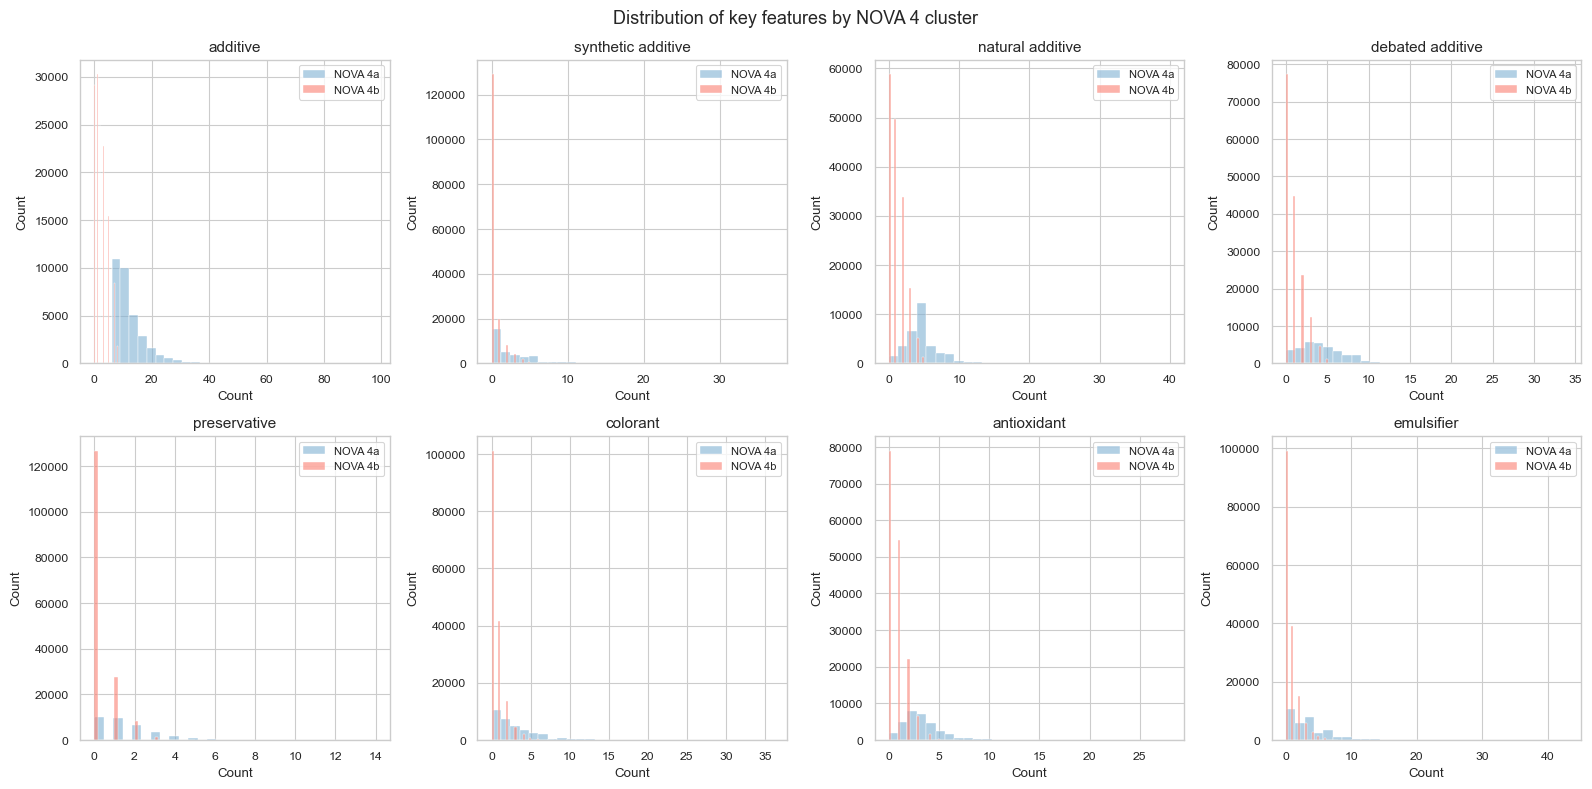

In [330]:
# Additive count distributions split by cluster for some key columns
key_count_cols = [
    'additive_count', 'synthetic_additive_count', 'natural_additive_count', 'debated_additive_count', 
    'preservative_count', 'colorant_count', 'antioxidant_count', 'emulsifier_count'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of key features by NOVA 4 cluster', fontsize=13)

cluster_colors = {0: set3[4], 1: set3[3]}
cluster_labels = {0: 'NOVA 4a', 1: 'NOVA 4b'}

for ax, col in zip(axes.flatten(), key_count_cols):
    for cl in [0, 1]:
        subset = df_nova4[df_nova4['nova4_cluster'] == cl][col]
        sns.histplot(subset, bins=30, ax=ax, alpha=0.6,
                     color=cluster_colors[cl],
                     label=cluster_labels[cl],
                     edgecolor='white', linewidth=0.3)
    ax.set_title(col.replace('_count', '').replace('_', ' '), fontsize=11)
    ax.set_xlabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 5. Nutri-score validation

Nutri-Score provides an independent external signal not used in the clustering.
If the clusters capture a meaningful difference in product quality, we would expect NOVA 4b (industrially reformulated) products to have a worse Nutri-Score profile than NOVA 4a products.

In [331]:
# Nutri-Score distribution by cluster
nutri_crosstab = pd.crosstab(
    df_nova4['nova4_cluster'],
    df_nova4['nutriscore_grade'],
    normalize='index'
).round(3) * 100

print("Nutri-Score grade distribution within each cluster (%):")
nutri_crosstab

Nutri-Score grade distribution within each cluster (%):


nutriscore_grade,a,b,c,d,e
nova4_cluster,,,,,
0,2.9,3.4,20.1,31.9,41.7
1,8.4,8.7,19.8,25.3,37.8


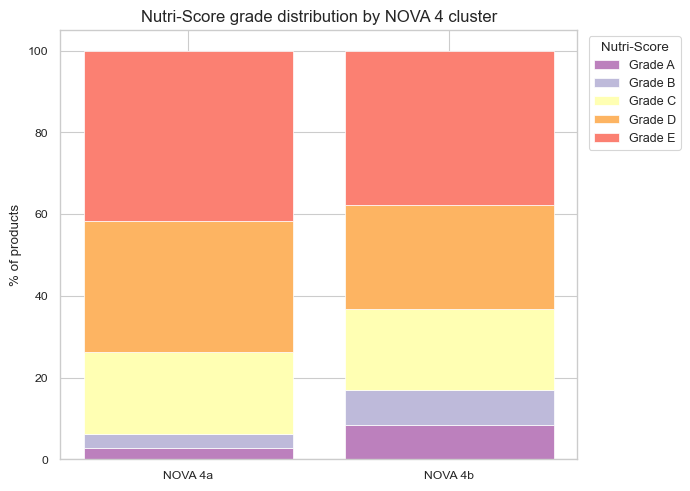

In [332]:
# Plot 6: Stacked bar chart — Nutri-Score grade by cluster
grade_order = ['a', 'b', 'c', 'd', 'e']
grade_colors = [set3[9], set3[2], set3[1], set3[5], set3[3]]

fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(2)
for grade, color in zip(grade_order, grade_colors):
    if grade in nutri_crosstab.columns:
        vals = nutri_crosstab[grade].values
        ax.bar(['NOVA 4a', 'NOVA 4b'], vals, bottom=bottom,
               color=color, edgecolor='white', linewidth=0.5, label=f'Grade {grade.upper()}')
        bottom += vals

ax.set_ylabel('% of products')
ax.set_ylim(0, 105)
ax.set_title('Nutri-Score grade distribution by NOVA 4 cluster', fontsize=12)
ax.legend(title='Nutri-Score', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [333]:
# just to check the validation in another way
df_nova4.groupby('nova4_cluster')[[
    'additive_count',
    'synthetic_additive_count',
    'emulsifier_count',
    'colorant_count'
]].mean()

,additive_count,synthetic_additive_count,emulsifier_count,colorant_count
nova4_cluster,,,,
0,12.569085,2.527579,3.170462,2.942669
1,2.707815,0.370645,0.661509,0.585637


# 6. LightGBM
Cluster assignments from K-Means were used as pseudo-labels for supervised binary classification.

This serves two purposes:
1. It allows generalisation of the subdivision to new products not yet in the dataset.
2. SHAP analysis on the trained model reveals which features most drive the
   4a/4b distinction, providing interpretable insight into what defines each subgroup.

The same 70/10/20 train/val/test split strategy used in the main NOVA pipeline
is retained here for methodological consistency.

In [334]:
# Define x and y (features and target)
X = df_nova4[final_feature_cols]
y = df_nova4['nova4_cluster']

In [335]:
# First split: train+val vs test
# holds out 20% as the test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, # input features, e.g. additive counts, synthetic counts, emulsifier counts
    y, # target labels, here nova4_cluster, meaning 4a vs 4b
    test_size=0.2, # Uses 20% of the products as a held-out test set and 80% for training and validation for the second split.
    stratify=y, # Keeps the same proportion of cluster 0 and cluster 1 in both train and test.
    random_state=42 # Makes the split reproducible, so we get the same train/test split every time we run it.
)

# Second split: train vs val
# Splits remaining 80% into train (70% total) and val (10% total)
# 0.125 × 0.80 = 0.10 of the full dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,  # 0.125 * 0.8 = 0.10 total (which is what we want)
    stratify=y_train_val,
    random_state=42
)

print(f"Train: {len(X_train)}")
print(f"Val:   {len(X_val)}")
print(f"Test:  {len(X_test)}")

Train: 137816
Val:   19688
Test:  39377


In [336]:
# Train LightGBM binary classifier
model_4ab = lgb.LGBMClassifier(
    objective='binary',        # binary classification: cluster 0 vs cluster 1
    n_estimators=300,          # maximum number of boosting trees/rounds
    learning_rate=0.05,        # smaller learning rate = slower but often more stable learning
    num_leaves=31,             # controls tree complexity - 31 is the LightGBM default
    class_weight='balanced',   # compensates for imbalance between 4a and 4b clusters
    random_state=42
)

# Fit model on training data and evaluate during training on validation data
# eval_set allows early stopping: training terminates when validation binary_logloss stops improving
model_4ab.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='binary_logloss'
)

print("Model trained.")

[LightGBM] [Info] Number of positive: 114947, number of negative: 22869
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 137816, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Model trained.


In [337]:
# only for validation set
# Evaluate predictions
y_val_pred = model_4ab.predict(X_val)
y_val_prob = model_4ab.predict_proba(X_val)[:, 1]

# Evaluation metrics
print(f"AUC-ROC : {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"F1 score: {f1_score(y_val, y_val_pred):.4f}")
print()
print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred,
                             target_names=['NOVA 4a', 'NOVA 4b']))


AUC-ROC : 1.0000
F1 score: 0.9988


Validation classification report:
              precision    recall  f1-score   support

     NOVA 4a       0.99      1.00      0.99      3267
     NOVA 4b       1.00      1.00      1.00     16421

    accuracy                           1.00     19688
   macro avg       1.00      1.00      1.00     19688
weighted avg       1.00      1.00      1.00     19688



In [338]:
# Test set evaluation (the final one that has been held-out)
# The test set was not seen during training or any modelling decisions,
# so these are the numbers to report in the paper.
y_test_pred = model_4ab.predict(X_test)
y_test_prob = model_4ab.predict_proba(X_test)[:, 1]

print("=== Test set (held-out) ===")
print(f"AUC-ROC : {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"F1 score: {f1_score(y_test, y_test_pred):.4f}")
print()
print(classification_report(y_test, y_test_pred,
                             target_names=['NOVA 4a', 'NOVA 4b']))

=== Test set (held-out) ===
AUC-ROC : 1.0000
F1 score: 0.9986

              precision    recall  f1-score   support

     NOVA 4a       0.99      1.00      0.99      6534
     NOVA 4b       1.00      1.00      1.00     32843

    accuracy                           1.00     39377
   macro avg       0.99      1.00      1.00     39377
weighted avg       1.00      1.00      1.00     39377



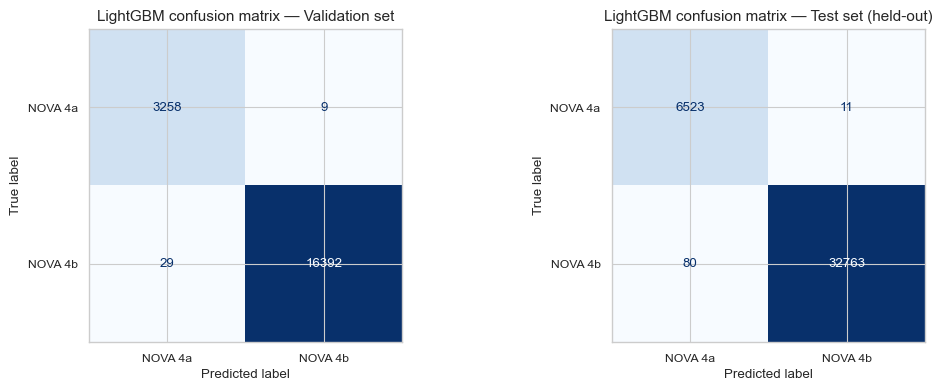

In [339]:
# Confusion matrices — validation and test
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val,  y_val_pred,  'Validation set'),
    (y_test, y_test_pred, 'Test set (held-out)')
]):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['NOVA 4a', 'NOVA 4b'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'LightGBM confusion matrix — {title}', fontsize=11)

plt.tight_layout()
plt.show()

# 7. SHAP Analysis

Here, SHAP values explains how each feature pushes a prediction toward NOVA 4b (positive SHAP) or
NOVA 4a (negative SHAP).

Reading the beeswarm plot:
- x-axis: SHAP value — positive pushes toward 4b, negative toward 4a
- colour: feature value — red = high, blue = low
- Each dot is one product in the validation set

In [340]:
# Create SHAP explainer
# TreeExplainer is the correct and efficient explainer for tree-based models like LightGBM. 
explainer = shap.TreeExplainer(model_4ab)

# Calculate SHAP values
# compute SHAP values on the test set so the explanations correspond to truly held-out data
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {len(X_test):,} test products")

SHAP values computed for 39,377 test products


/Users/sofiebojgaardthomsen/Documents/Data_Science/DataScience2026/env/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


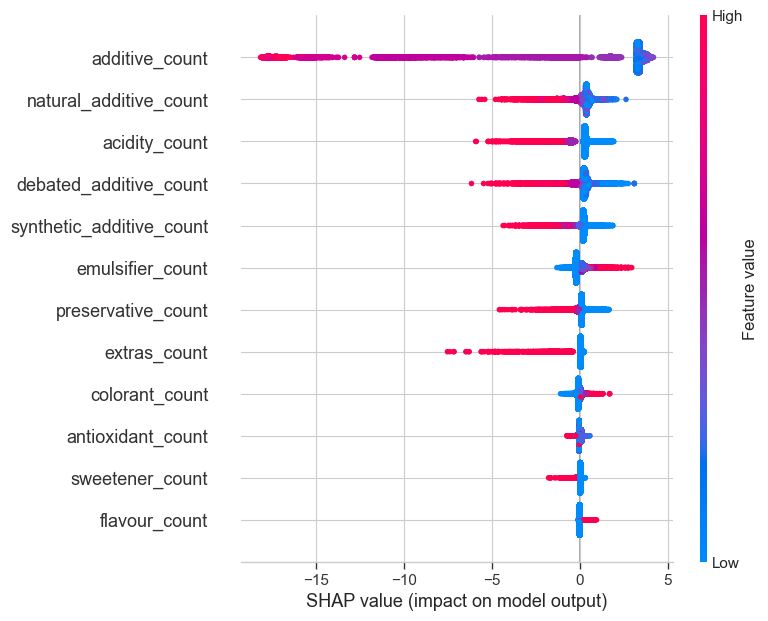

In [341]:
# SHAP beeswarm summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=final_feature_cols,
    show=True
)
# Each dot is a product. 
# Dots to the right (positive SHAP) push the prediction toward NOVA 4b.
# Colour encodes the feature value: red = high, blue = low.
# Key finding: additive_count is overwhelmingly dominant — it is the
# degree of industrial reformulation, not merely the presence of
# synthetic additives, that best separates the two subgroups.


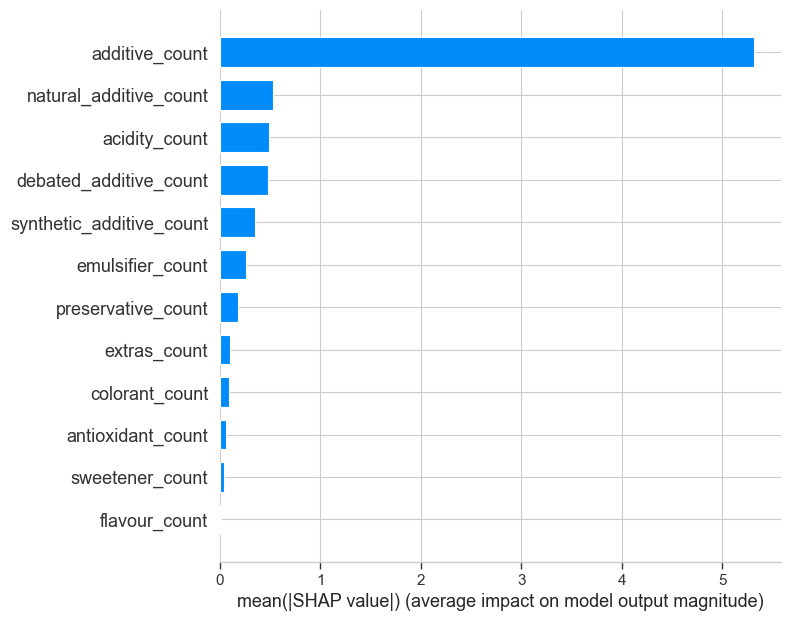

In [342]:
# SHAP bar plot — mean absolute importance
# The bar plot collapses direction and shows which features matter most on average. 
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=final_feature_cols,
    plot_type='bar',
    show=True
)

# Cluster label interpretation
Based on the cluster centres, SHAP analysis, and Nutri-Score validation:

NOVA 4a = “Cosmetically processed”
- lower overall additive complexity
- fewer industrial additive categories in use
- Higher share of natural-only additive products
- Better Nutri-Score profile on average

NOVA 4b = “Industrially reformulated”
- High additive burden: substantially more additives per product
- Extensive use of preservatives, emulsifiers, and colorants
- Higher synthetic additive load
- Worse Nutri-Score profile; substantially more grade E products
- Represents ~19% of NOVA 4 products — a meaningful minority, not noise

Thus, it's no longer:
“synthetic additives define ultra-processing.”

Instead it's:
“industrial reformulation intensity defines a meaningful internal structure within NOVA 4.”



